# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [1]:
import pandas as pd

df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

sns.set_style('whitegrid')

## Part 1: Which feature has the strongest linear relationship with productivity?

Comparing R² for `YearsAtCompany`, `HoursWorked`, and `FocusScore`.

In [3]:
for feat in ['YearsAtCompany', 'HoursWorked', 'FocusScore']:
    slope, intercept, r_value, p_value, std_err = linregress(df[feat], df['ProductivityScore'])
    print(f'{feat}: R-squared = {r_value**2:.4f}')

YearsAtCompany: R-squared = 0.0004
HoursWorked: R-squared = 0.0026
FocusScore: R-squared = 0.6777


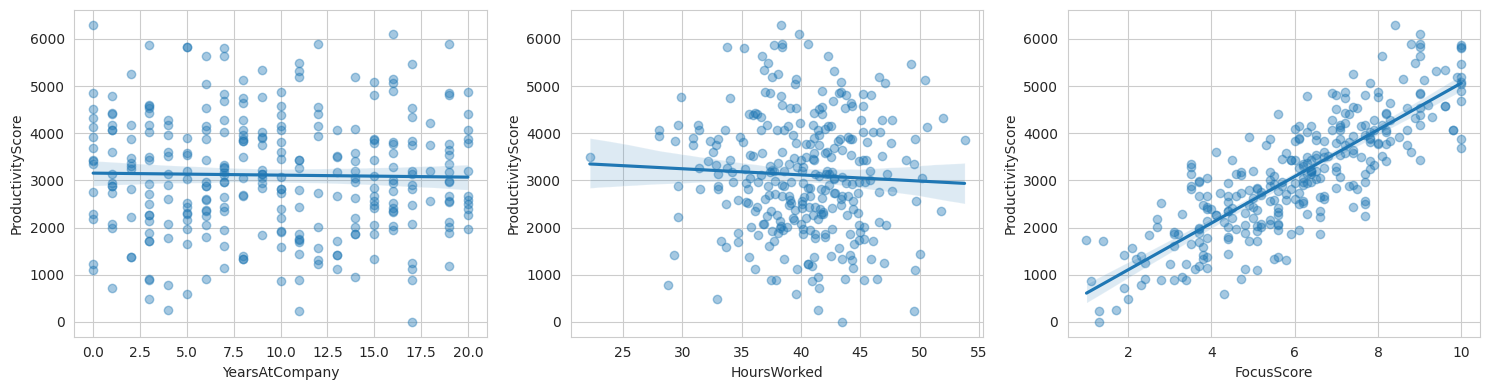

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, feat in zip(axes, ['YearsAtCompany', 'HoursWorked', 'FocusScore']):
    sns.regplot(data=df, x=feat, y='ProductivityScore', ax=ax, scatter_kws={'alpha':0.4})
plt.tight_layout()
plt.show()

**FocusScore has the strongest relationship with productivity (R² ≈ 0.68).** `YearsAtCompany` and `HoursWorked` are both close to R² = 0, so neither one has a real linear relationship with productivity.

## Part 2: What else affects productivity?

Checking the remaining features: `TeamMeetingsPerWeek`, `DeskLocation`, and `Department`.

TeamMeetingsPerWeek: R-squared = 0.0542


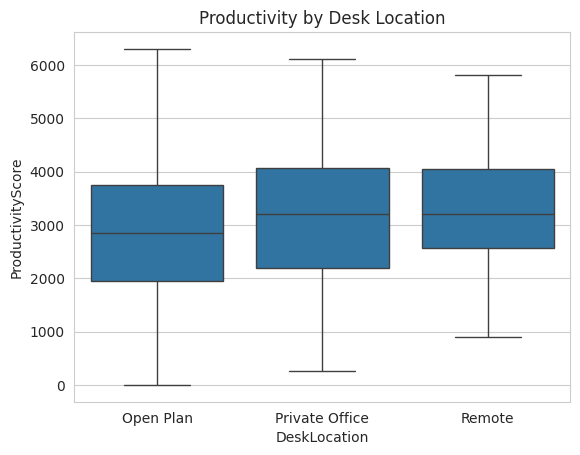

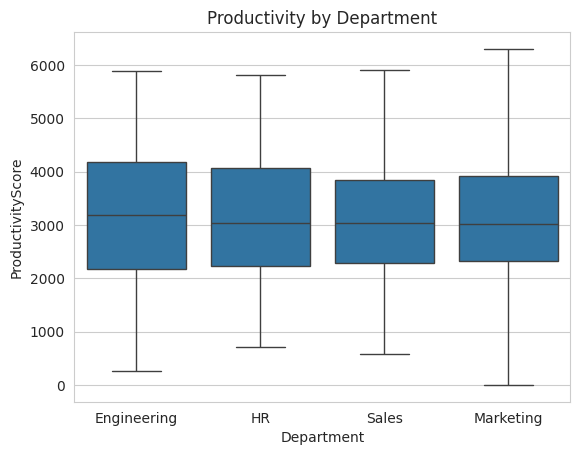

In [5]:
slope, intercept, r_value, p_value, std_err = linregress(df['TeamMeetingsPerWeek'], df['ProductivityScore'])
print(f'TeamMeetingsPerWeek: R-squared = {r_value**2:.4f}')

sns.boxplot(data=df, x='DeskLocation', y='ProductivityScore')
plt.title('Productivity by Desk Location')
plt.show()

sns.boxplot(data=df, x='Department', y='ProductivityScore')
plt.title('Productivity by Department')
plt.show()

`TeamMeetingsPerWeek` has a weak relationship on its own (R² ≈ 0.05). `DeskLocation` shows some difference between groups (Open Plan looks lowest). `Department` looks about the same across all four groups — no real effect there.

In [6]:
import statsmodels.formula.api as smf

model = smf.ols('ProductivityScore ~ FocusScore + C(DeskLocation)', data=df).fit()
print('R-squared:', round(model.rsquared, 4))
print(model.params)

R-squared: 0.6819
Intercept                            153.031885
C(DeskLocation)[T.Private Office]    -91.597233
C(DeskLocation)[T.Remote]           -207.968544
FocusScore                           504.238920
dtype: float64


Adding `DeskLocation` to `FocusScore` only bumps R² up slightly (from 0.68 to about 0.68), so **FocusScore is doing almost all the work**. `YearsAtCompany`, `HoursWorked`, `TeamMeetingsPerWeek`, and `Department` don't meaningfully improve the model once `FocusScore` is already in it.

## Part 3: Summary

Productivity is mostly driven by `FocusScore` — it alone explains about 68% of the variation, far more than any other feature. Tenure, hours worked, meetings, and department don't show a meaningful relationship with productivity. Desk location has a small effect, with Open Plan looking worse than the alternatives. My recommendation: focus on things that help employees concentrate (fewer distractions, maybe reconsider the open floor plan) rather than worrying about tenure, overtime, or which department someone is in — those don't seem to matter.